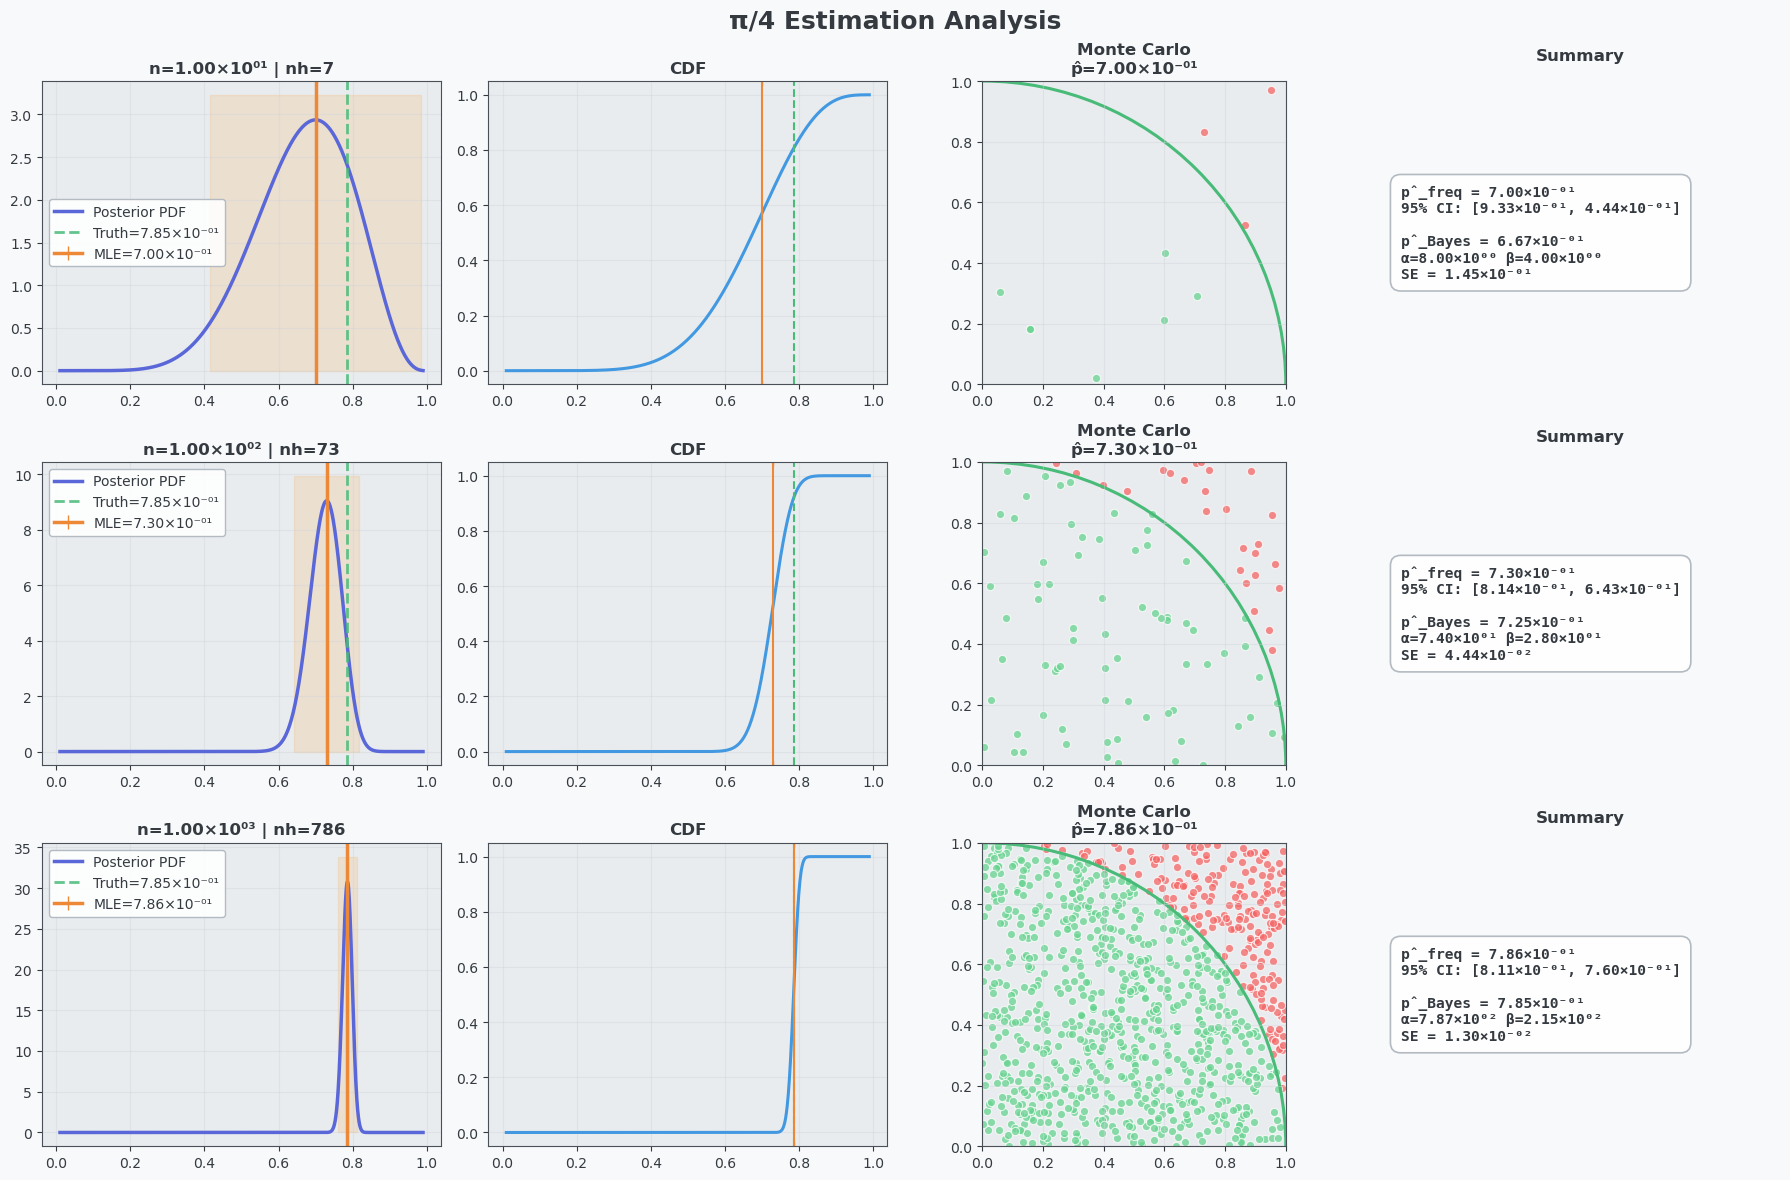

────────────────────────────────────────────────────────────────────────────────────────
  π/4 Estimation Analysis  
p̂ = n_h/n (MLE)  |  Posterior Mean (Bayes)
────────────────────────────────────────────────────────────────────────────────────────
              n            p̂_freq           p̂_Bayes            True        4p̂_freq       4p̂_Bayes
────────────────────────────────────────────────────────────────────────────────────────
      1.00×10⁰¹        7.00×10⁻⁰¹        6.67×10⁻⁰¹     7.85×10⁻⁰¹      2.80×10⁰⁰      2.67×10⁰⁰
      1.00×10⁰²        7.30×10⁻⁰¹        7.25×10⁻⁰¹     7.85×10⁻⁰¹      2.92×10⁰⁰      2.90×10⁰⁰
      1.00×10⁰³        7.86×10⁻⁰¹        7.85×10⁻⁰¹     7.85×10⁻⁰¹      3.14×10⁰⁰      3.14×10⁰⁰
────────────────────────────────────────────────────────────────────────────────────────
Celestial Twilight Plot: pi_celestial_grids.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
from scipy.special import gammaln
from scipy.optimize import brentq
from scipy.integrate import cumulative_trapezoid as cumtrapz, trapezoid



# Soothing ANSI colors
class Colors:
    SOFT_BLUE = '\033[94m'
    SOFT_GREEN = '\033[92m'
    SOFT_YELLOW = '\033[93m'
    SOFT_CYAN = '\033[96m'
    SOFT_MAGENTA = '\033[95m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    DIM = '\033[2m'

# Abstract Soothing: Celestial Twilight (VISIBLE GRIDS)
plt.style.use('default')
plt.rcParams['figure.facecolor'] = '#F8F9FA'  # Ghost white
plt.rcParams['figure.edgecolor'] = '#6C757D'  # Gray
plt.rcParams['axes.facecolor'] = '#E9ECEF'    # Light gray
plt.rcParams['axes.edgecolor'] = '#495057'    # Dark gray
plt.rcParams['text.color'] = '#343A40'        # Dark gray
plt.rcParams['axes.labelcolor'] = '#343A40'
plt.rcParams['xtick.color'] = '#343A40'
plt.rcParams['ytick.color'] = '#343A40'
plt.rcParams['legend.facecolor'] = 'white'
plt.rcParams['legend.edgecolor'] = '#ADB5BD'

def sci_not_proper(x, prec=2):
    s = f"{x:.{prec}e}"
    mantissa, exp = s.split('e')
    exp_map = {'0':'⁰','1':'¹','2':'²','3':'³','4':'⁴','5':'⁵','6':'⁶','7':'⁷','8':'⁸','9':'⁹'}
    
    if exp[0] == '-':
        sign = '⁻'
        exp_digits = exp[1:]
    elif exp[0] == '+':
        sign = ''
        exp_digits = exp[1:]
    else:
        sign = ''
        exp_digits = exp
    
    exp_super = ''.join(exp_map.get(c, c) for c in exp_digits)
    return f"{mantissa}×10{sign}{exp_super}"

p_hat = 'p̂'
pi_sym = 'π'

def generate_mc_data(n, seed=None):
    if seed is not None:
        np.random.seed(seed)
    x = np.random.rand(n)
    y = np.random.rand(n)
    r = np.sqrt(x**2 + y**2)
    nh = np.sum(r <= 1)
    return x, y, r, nh

def clopper_pearson_ci(nh, n, alpha=0.05):
    def invert_binom(p, k, n):
        def func(q):
            return binom.cdf(k, n, q) - p
        return brentq(func, 0, 1)
    lo = invert_binom(alpha/2, nh, n)
    hi = invert_binom(1 - alpha/2, nh, n)
    return lo, hi

def bayes_posterior_pdf(r, n, theta_grid, prior_a=1, prior_b=1):
    nh = np.sum(r <= 1)
    alpha_post = prior_a + nh
    beta_post = prior_b + (n - nh)
    log_pdf = (gammaln(alpha_post + beta_post) - gammaln(alpha_post) - gammaln(beta_post) + 
               (alpha_post - 1)*np.log(theta_grid + 1e-10) + (beta_post - 1)*np.log(1 - theta_grid + 1e-10))
    pdf = np.exp(log_pdf - np.max(log_pdf))
    pdf /= trapezoid(pdf, theta_grid)
    post_mean = alpha_post / (alpha_post + beta_post)
    return pdf, post_mean, (alpha_post, beta_post)

# Celestial Twilight Plot with PROMINENT GRIDS
ns = [10, 100, 1000]
seeds = [42, 43, 44]
true_p = np.pi / 4

fig = plt.figure(figsize=(18, 12), facecolor='#F8F9FA', edgecolor='#6C757D')
fig.suptitle(f'{pi_sym}/4 Estimation Analysis', fontsize=18, color='#343A40', weight='bold')

theta = np.linspace(0.01, 0.99, 1000)

for i, (n, seed) in enumerate(zip(ns, seeds)):
    x, y, r, nh = generate_mc_data(n, seed)
    p_freq = nh / n
    ci_lo, ci_hi = clopper_pearson_ci(nh, n)
    post_pdf, post_mean, post_shape = bayes_posterior_pdf(r, n, theta)
    se_laplace = np.sqrt(p_freq * (1 - p_freq) / n)
    
    # 1. PDF - VISIBLE GRID
    ax_pdf = plt.subplot(3, 4, i*4 + 1)
    ax_pdf.plot(theta, post_pdf, '#5A67D8', linewidth=2.5, label='Posterior PDF')
    ax_pdf.axvline(true_p, color='#48BB78', ls='--', alpha=0.85, lw=2, label=f'Truth={sci_not_proper(true_p)}')
    ax_pdf.axvline(p_freq, color='#ED8936', marker='|', ms=10, lw=2.5, label=f'MLE={sci_not_proper(p_freq)}')
    ax_pdf.fill_betweenx([0, np.max(post_pdf)*1.1], p_freq-1.96*se_laplace, p_freq+1.96*se_laplace, 
                        alpha=0.2, color='#F6AD55')
    ax_pdf.legend(framealpha=0.9)
    ax_pdf.grid(True, alpha=0.4, color='#CED4DA', linestyle='-', linewidth=0.8)  # VISIBLE GRID
    ax_pdf.set_title(f'n={sci_not_proper(n)} | nh={nh}', color='#343A40', weight='bold')
    
    # 2. CDF - VISIBLE GRID
    ax_cdf = plt.subplot(3, 4, i*4 + 2)
    cdf_bayes = cumtrapz(post_pdf, theta, initial=0)
    cdf_bayes /= cdf_bayes[-1]
    ax_cdf.plot(theta, cdf_bayes, '#4299E1', linewidth=2.2)
    ax_cdf.axvline(true_p, color='#48BB78', ls='--')
    ax_cdf.axvline(p_freq, color='#ED8936', marker='|')
    ax_cdf.grid(True, alpha=0.4, color='#CED4DA', linestyle='-', linewidth=0.8)  # VISIBLE GRID
    ax_cdf.set_title('CDF', color='#343A40', weight='bold')
    
    # 3. Scatter - VISIBLE GRID
    ax_scatter = plt.subplot(3, 4, i*4 + 3)
    inside = r <= 1
    ax_scatter.scatter(x[~inside], y[~inside], c='#F56565', s=35, alpha=0.75, ec='white', lw=0.8)
    ax_scatter.scatter(x[inside], y[inside], c='#68D391', s=35, alpha=0.75, ec='white', lw=0.8)
    circle = plt.Circle((0, 0), 1, fc='none', ec='#48BB78', lw=2.2)
    ax_scatter.add_patch(circle)
    ax_scatter.grid(True, alpha=0.4, color='#CED4DA', linestyle='-', linewidth=0.8)  # VISIBLE GRID
    ax_scatter.set(aspect='equal', xlim=(0,1), ylim=(0,1))
    ax_scatter.set_title(f'Monte Carlo\n{p_hat}={sci_not_proper(p_freq)}', color='#343A40', weight='bold')
    
    # 4. Stats
    ax_table = plt.subplot(3, 4, i*4 + 4)
    ax_table.axis('off')
    textstr = (f'{p_hat}_freq = {sci_not_proper(p_freq)}\n'
               f'95% CI: [{sci_not_proper(ci_lo)}, {sci_not_proper(ci_hi)}]\n\n'
               f'{p_hat}_Bayes = {sci_not_proper(post_mean)}\n'
               f'α={sci_not_proper(post_shape[0])} β={sci_not_proper(post_shape[1])}\n'
               f'SE = {sci_not_proper(se_laplace)}')
    ax_table.text(0.05, 0.5, textstr, fontsize=10.5, va='center', family='monospace', 
                  color='#343A40', weight='bold',
                  bbox=dict(boxstyle='round,pad=0.7', fc='white', ec='#ADB5BD', lw=1.2, alpha=0.92))
    ax_table.set_title('Summary', color='#343A40', weight='bold', pad=15)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('pi_celestial_grids.png', dpi=300, facecolor='#F8F9FA', bbox_inches='tight', edgecolor='#6C757D')
plt.show()

# Clean Console Output
print(Colors.BOLD + Colors.SOFT_CYAN + '─'*88 + Colors.ENDC)
print(Colors.BOLD + Colors.SOFT_MAGENTA + f'  {pi_sym}/4 Estimation Analysis  ' + Colors.ENDC)
print(Colors.DIM + Colors.SOFT_GREEN + f'{p_hat} = n_h/n (MLE)  |  Posterior Mean (Bayes)' + Colors.ENDC)
print(Colors.BOLD + Colors.SOFT_CYAN + '─'*88 + Colors.ENDC)
header = f"{Colors.SOFT_BLUE}{'n':>15}{Colors.SOFT_YELLOW} {'p̂_freq':>18}{Colors.SOFT_GREEN} {'p̂_Bayes':>18}{Colors.SOFT_CYAN} {'True':>15}{Colors.SOFT_MAGENTA} {'4p̂_freq':>15}{Colors.SOFT_BLUE} {'4p̂_Bayes':>15}"
print(header + Colors.ENDC)
print(Colors.BOLD + Colors.SOFT_CYAN + '─'*88 + Colors.ENDC)
for n, seed in zip(ns, seeds):
    x, y, r, nh = generate_mc_data(n, seed)
    p_freq = nh / n
    post_pdf, p_bayes, _ = bayes_posterior_pdf(r, n, theta)
    row = (f"{Colors.SOFT_BLUE}{sci_not_proper(n):>15}{Colors.SOFT_YELLOW}{sci_not_proper(p_freq):>18}"
           f"{Colors.SOFT_GREEN}{sci_not_proper(p_bayes):>18}{Colors.SOFT_CYAN}{sci_not_proper(true_p):>15}"
           f"{Colors.SOFT_MAGENTA}{sci_not_proper(4*p_freq):>15}{Colors.SOFT_BLUE}{sci_not_proper(4*p_bayes):>15}")
    print(row + Colors.ENDC)
print(Colors.BOLD + Colors.SOFT_CYAN + '─'*88 + Colors.ENDC)
print(Colors.BOLD + Colors.SOFT_GREEN + 'Celestial Twilight Plot: pi_celestial_grids.png' + Colors.ENDC)
